In [1]:
# Heatmaps

In [2]:
!pwd

/mnt/c/Users/vvasileiou/Desktop/lncAPNet/Pilot_2_Prostate/notebooks/Post-hoc_Analysis


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# Hierarchical clustering

In [45]:
res_tcga = pd.read_excel("../../results/TCGA/TCGA_NetBID2_ms_tab.xlsx")
res_tcga = res_tcga[['originalID', 'funcType', 'Size',
                     'logFC.U.Vs.M_DA', 'adj.P.Val.U.Vs.M_DA', 'Z.U.Vs.M_DA',
                     'logFC.U.Vs.M_DE', 'adj.P.Val.U.Vs.M_DE', 'Z.U.Vs.M_DE']]

res_tcga.rename(columns={
    'originalID': 'ID',
    'funcType': 'Type',
    'logFC.U.Vs.M_DA': 'logFC_DA',
    'adj.P.Val.U.Vs.M_DA': 'adj.P.Val_DA',
    'Z.U.Vs.M_DA': 'Z-score_DA',
    'logFC.U.Vs.M_DE': 'logFC_DE',
    'adj.P.Val.U.Vs.M_DE': 'adj.P.Val_DE',
    'Z.U.Vs.M_DE': 'Z-score_DE',
}, inplace=True)

# Create a temporary column to give priority to "TF" rows
res_tcga['priority'] = res_tcga['Type'].apply(lambda x: 0 if x == 'TF' else 1)

# Sort by priority and ID
res_tcga = res_tcga.sort_values(by=['priority', 'ID'])

# Drop duplicates, keeping TF first
res_tcga = res_tcga.drop_duplicates(subset='ID', keep='first')

# Drop helper column
res_tcga = res_tcga.drop(columns=['priority'])

# Apply filters
res_tcga_filt_overt = res_tcga[
    (res_tcga['adj.P.Val_DA'] < 0.05) &
    (res_tcga['adj.P.Val_DE'] < 0.05) &
    (res_tcga['Size'] > 30)
]

res_tcga_filt_hidden = res_tcga[
    (res_tcga['adj.P.Val_DA'] < 0.05) &
    (res_tcga['adj.P.Val_DE'] > 0.05) &
    (res_tcga['Size'] > 30)
]

# Print summary
print("Overt Drivers:", len(res_tcga_filt_overt))
print("Hidden Drivers:", len(res_tcga_filt_hidden))
print("Overt TFs:", len(res_tcga_filt_overt[res_tcga_filt_overt['Type'] == "TF"]))
print("Overt SIGs:", len(res_tcga_filt_overt[res_tcga_filt_overt['Type'] == "SIG"]))
print("Overt NCs:", len(res_tcga_filt_overt[res_tcga_filt_overt['Type'] == "NC"]))
print("Hidden TFs:", len(res_tcga_filt_hidden[res_tcga_filt_hidden['Type'] == "TF"]))
print("Hidden SIGs:", len(res_tcga_filt_hidden[res_tcga_filt_hidden['Type'] == "SIG"]))
print("Hidden NCs:", len(res_tcga_filt_hidden[res_tcga_filt_hidden['Type'] == "NC"]))


Overt Drivers: 2609
Hidden Drivers: 1722
Overt TFs: 380
Overt SIGs: 1283
Overt NCs: 946
Hidden TFs: 290
Hidden SIGs: 649
Hidden NCs: 783


In [71]:
shap_validation_go = pd.read_csv("../../PASNet/Output/GO/feature_importance_table.csv", index_col=0)
shap_validation_go_top20 = shap_validation_go.sort_values(by="Importance", ascending=False).head(50)

shap_validation_rest = pd.read_csv("../../PASNet/Output/REST/feature_importance_table.csv", index_col=0)
shap_validation_rest_top20 = shap_validation_rest.sort_values(by="Importance", ascending=False).head(50)

In [72]:
# Step 1: Get the feature names (index) from both DataFrames
features_rest = shap_validation_rest_top20.index
features_go = shap_validation_go_top20.index

# Step 2: Combine the feature names
combined_features = features_rest.to_list() + features_go.to_list()

# Step 3: Remove duplicates
unique_features = pd.Index(combined_features).unique()

# Optional: Convert to DataFrame if needed
features_df = pd.DataFrame(unique_features, columns=['Feature'])

In [73]:
res_tcga_filt = res_tcga[res_tcga['ID'].isin(features_df['Feature'])]
len(res_tcga_filt)

84

In [74]:
res_tcga_filt[res_tcga_filt['Type'] == "NC"]['ID'].tolist()

['FRY-AS1', 'HCG11', 'HLA-DQB1-AS1', 'LINC01082', 'LINC01088', 'PRC1-AS1']

/home/vvasileiou/miniconda3/envs/lncAPNet/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/vvasileiou/miniconda3/envs/lncAPNet/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


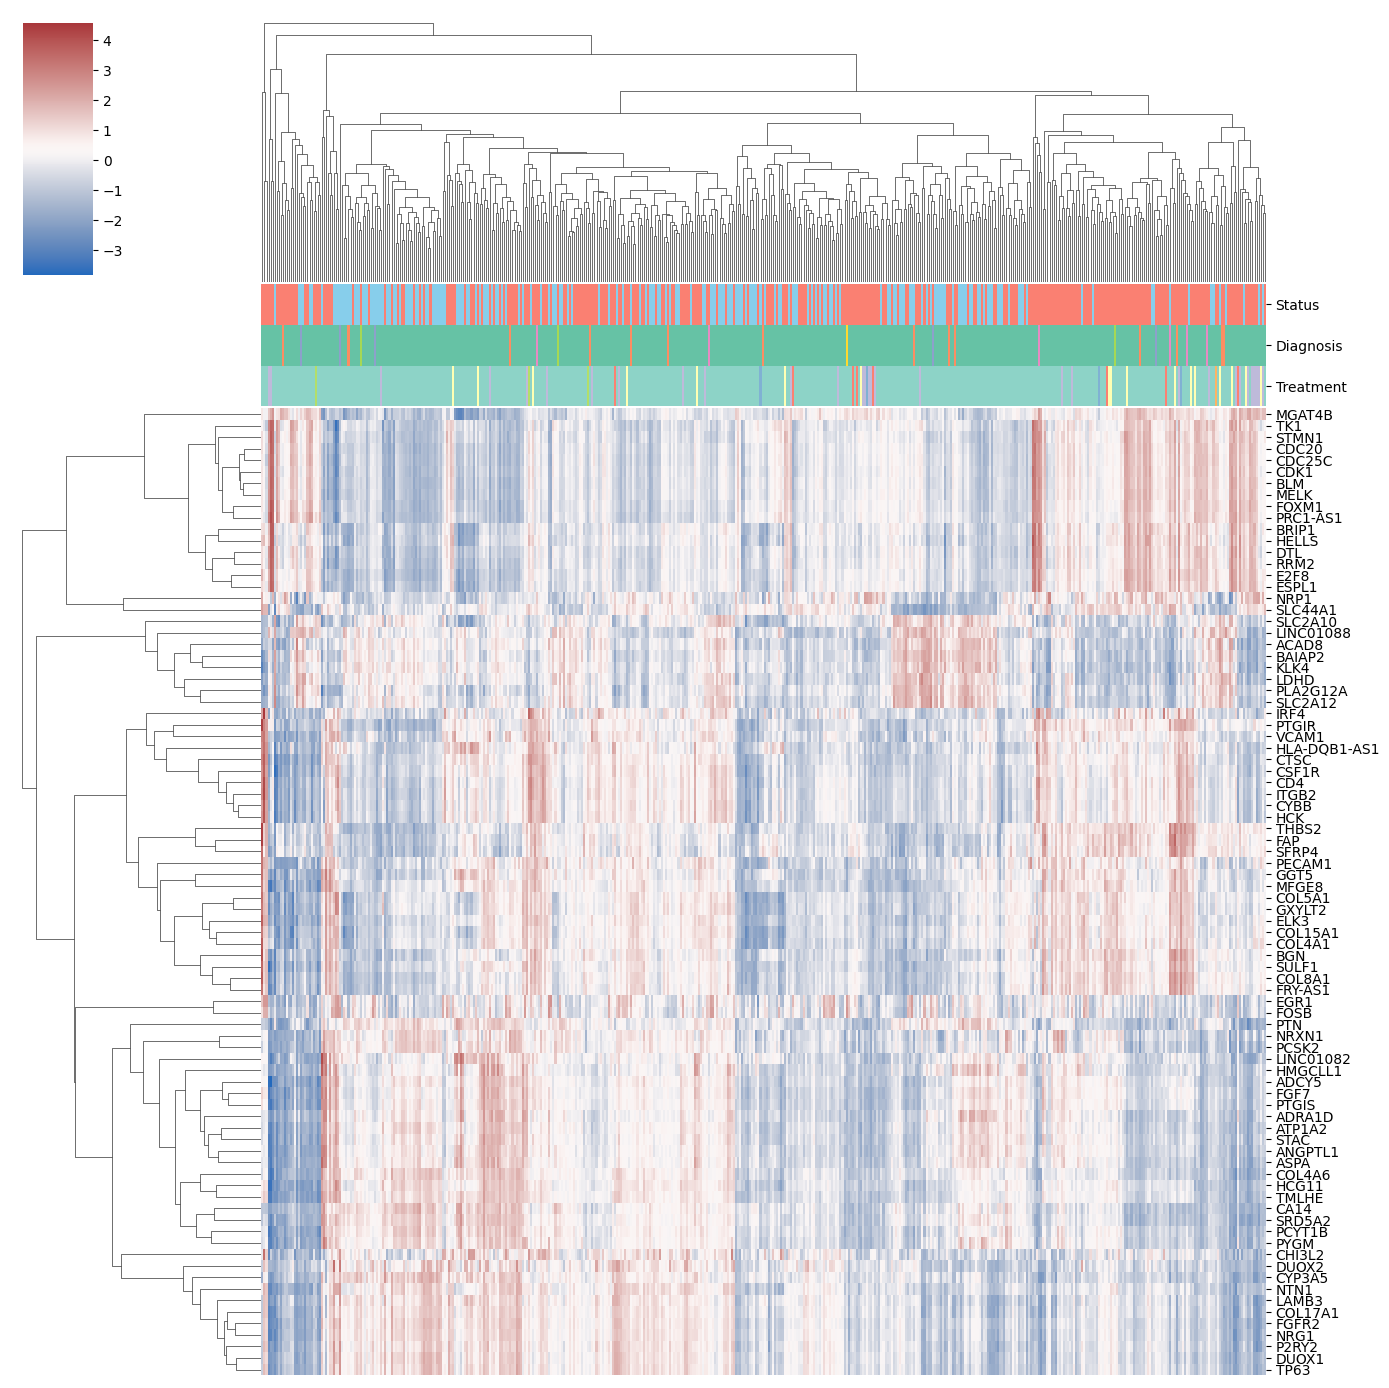

In [76]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
count_matrix = pd.read_csv("../../data/TCGA/activity_ens.csv", index_col=0)
clinical = pd.read_excel("../../data/TCGA/clinical_info.xlsx")

# Set Sample_ID as index
clinical = clinical.set_index('Sample_ID')

# Keep only samples present in both datasets
common_samples = count_matrix.columns.intersection(clinical.index)
count_matrix = count_matrix[common_samples]
clinical = clinical.loc[common_samples]

# Subset genes of interest
genes_of_interest = res_tcga_filt['ID'].tolist()  # replace with your gene symbols
count_matrix_subset = count_matrix.loc[count_matrix.index.intersection(genes_of_interest)]

# Create color palettes for annotations
status_colors = {'Mild': 'skyblue', 'Progressive': 'salmon'}
diagnosis_colors = {cls: color for cls, color in zip(clinical['diagnoses.classification_of_tumor'].unique(), sns.color_palette("Set2", n_colors=clinical['diagnoses.classification_of_tumor'].nunique()))}
treatment_colors = {out: color for out, color in zip(clinical['treatments.treatment_outcome'].unique(), sns.color_palette("Set3", n_colors=clinical['treatments.treatment_outcome'].nunique()))}

# Map clinical annotations to colors
col_colors = pd.DataFrame({
    'Status': clinical['Status'].map(status_colors),
    'Diagnosis': clinical['diagnoses.classification_of_tumor'].map(diagnosis_colors),
    'Treatment': clinical['treatments.treatment_outcome'].map(treatment_colors)
})

# Plot clustered heatmap
g = sns.clustermap(
    count_matrix_subset,
    cmap="vlag",
    z_score=0,           # row-wise z-score normalization
    row_cluster=True,
    col_cluster=True,
    col_colors=col_colors,
    xticklabels=False,
    yticklabels=True,
    figsize=(14, 14)
)

# Save figure
g.fig.savefig("../../figures/TCGA_clustermap.png", dpi=300)
plt.show()


In [ ]:
# lncRNAs only

/home/vvasileiou/miniconda3/envs/lncAPNet/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/vvasileiou/miniconda3/envs/lncAPNet/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


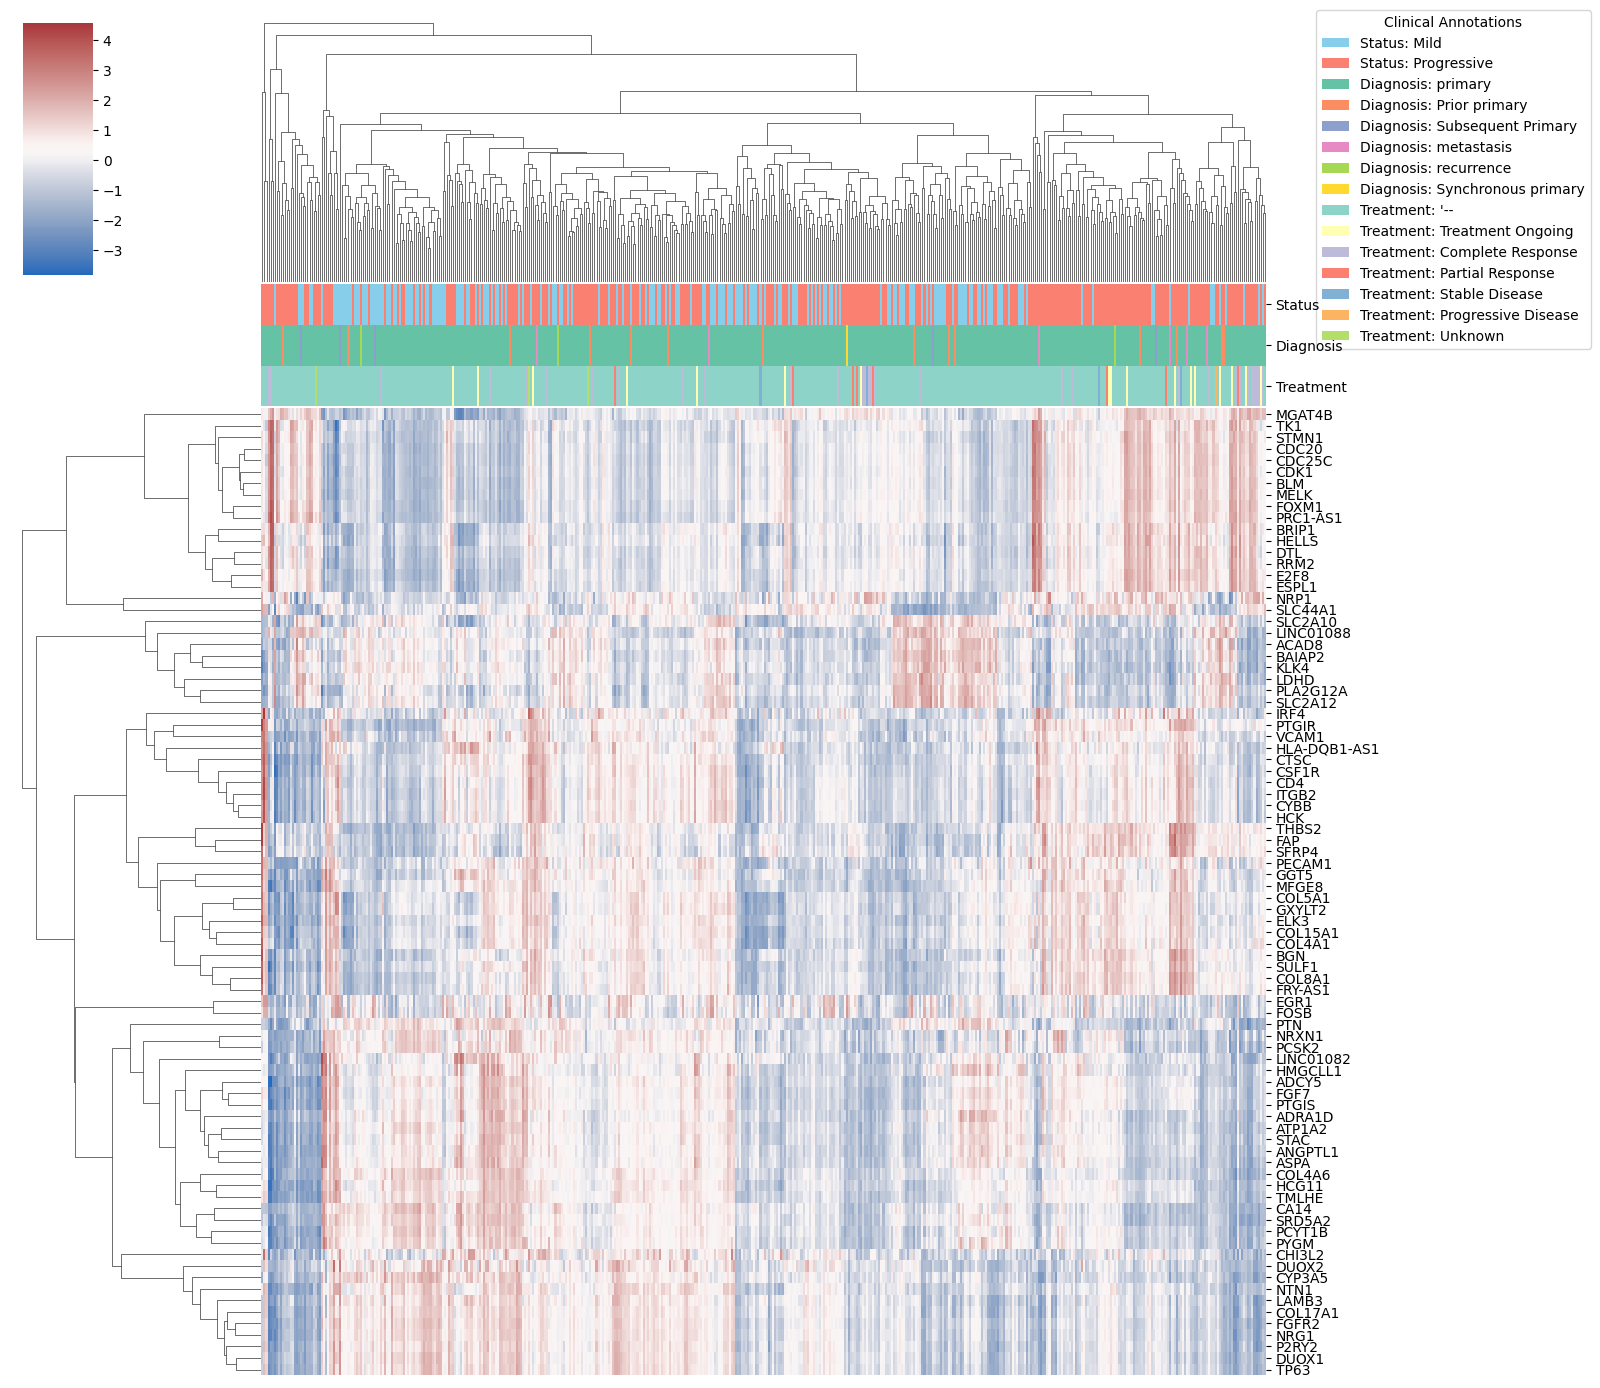

In [77]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Load data
count_matrix = pd.read_csv("../../data/TCGA/activity_ens.csv", index_col=0)
clinical = pd.read_excel("../../data/TCGA/clinical_info.xlsx")

# Set Sample_ID as index
clinical = clinical.set_index('Sample_ID')

# Keep only samples present in both datasets
common_samples = count_matrix.columns.intersection(clinical.index)
count_matrix = count_matrix[common_samples]
clinical = clinical.loc[common_samples]

# Subset genes of interest
genes_of_interest = res_tcga_filt['ID'].tolist()  # replace with your gene symbols
count_matrix_subset = count_matrix.loc[count_matrix.index.intersection(genes_of_interest)]

# Create color palettes for annotations
status_colors = {'Mild': 'skyblue', 'Progressive': 'salmon'}
diagnosis_colors = {cls: color for cls, color in zip(clinical['diagnoses.classification_of_tumor'].unique(), sns.color_palette("Set2", n_colors=clinical['diagnoses.classification_of_tumor'].nunique()))}
treatment_colors = {out: color for out, color in zip(clinical['treatments.treatment_outcome'].unique(), sns.color_palette("Set3", n_colors=clinical['treatments.treatment_outcome'].nunique()))}

# Map clinical annotations to colors
col_colors = pd.DataFrame({
    'Status': clinical['Status'].map(status_colors),
    'Diagnosis': clinical['diagnoses.classification_of_tumor'].map(diagnosis_colors),
    'Treatment': clinical['treatments.treatment_outcome'].map(treatment_colors)
})

# Plot clustered heatmap
g = sns.clustermap(
    count_matrix_subset,
    cmap="vlag",
    z_score=0,           # row-wise z-score normalization
    row_cluster=True,
    col_cluster=True,
    col_colors=col_colors,
    xticklabels=False,
    yticklabels=True,
    figsize=(14, 14)
)

# Create legends
legend_patches = []
for label, color in status_colors.items():
    legend_patches.append(Patch(facecolor=color, label=f'Status: {label}'))
for label, color in diagnosis_colors.items():
    legend_patches.append(Patch(facecolor=color, label=f'Diagnosis: {label}'))
for label, color in treatment_colors.items():
    legend_patches.append(Patch(facecolor=color, label=f'Treatment: {label}'))

# Add legend outside the heatmap
g.ax_col_dendrogram.legend(
    handles=legend_patches,
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.,
    title='Clinical Annotations'
)

# Save figure
#g.fig.savefig("../../figures/TCGA_clustermap_with_labels.png", dpi=300, bbox_inches='tight')
plt.show()


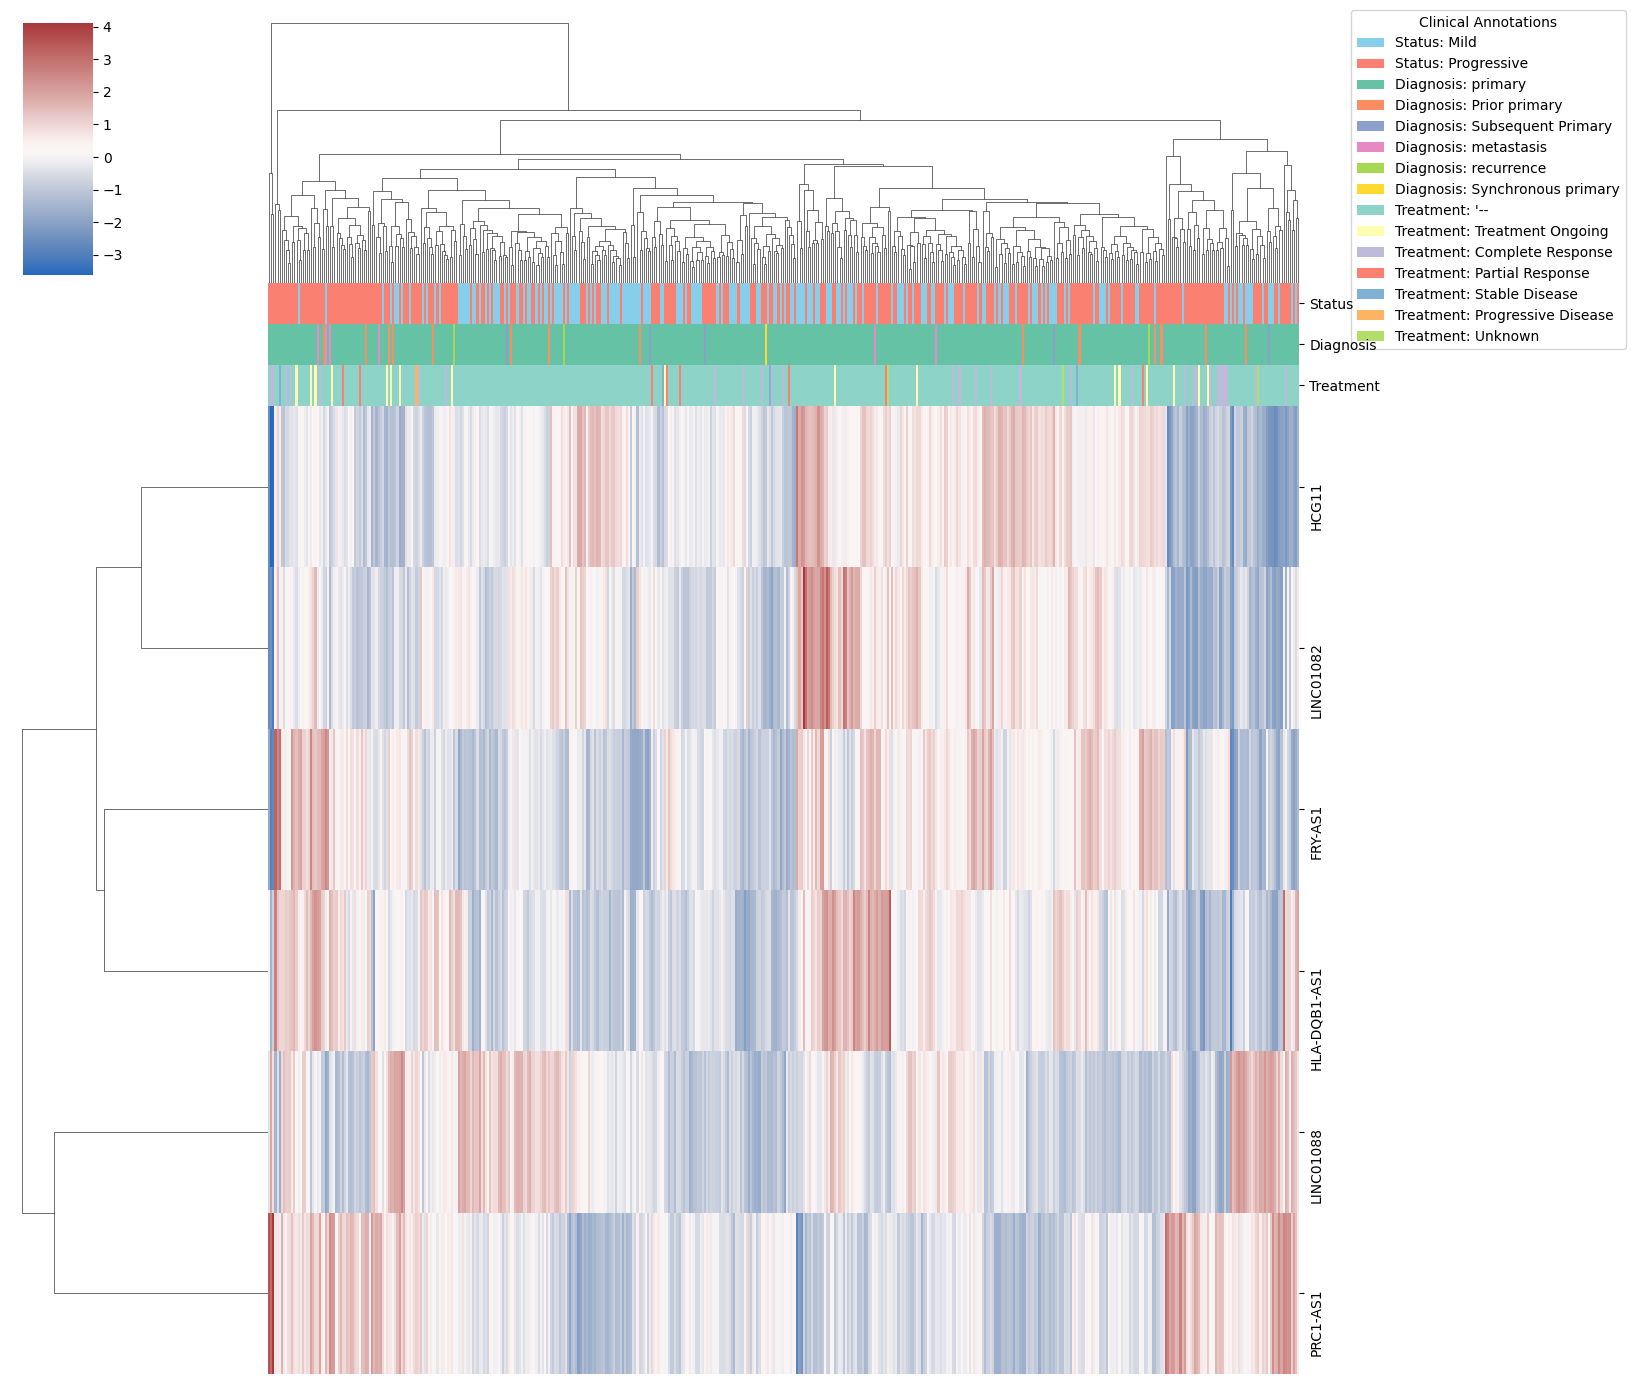

In [80]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Load data
count_matrix = pd.read_csv("../../data/TCGA/activity_ens.csv", index_col=0)
clinical = pd.read_excel("../../data/TCGA/clinical_info.xlsx")

# Set Sample_ID as index
clinical = clinical.set_index('Sample_ID')

# Keep only samples present in both datasets
common_samples = count_matrix.columns.intersection(clinical.index)
count_matrix = count_matrix[common_samples]
clinical = clinical.loc[common_samples]

# Subset genes of interest
genes_of_interest = res_tcga_filt['ID'].tolist()  # replace with your gene symbols
count_matrix_subset = count_matrix.loc[count_matrix.index.intersection(genes_of_interest)]

# Subset genes of interest
genes_of_interest = res_tcga_filt[res_tcga_filt['Type'] == "NC"]['ID'].tolist()  # replace with your gene symbols
count_matrix_subset = count_matrix.loc[count_matrix.index.intersection(genes_of_interest)]

# Create color palettes for annotations
status_colors = {'Mild': 'skyblue', 'Progressive': 'salmon'}
diagnosis_colors = {cls: color for cls, color in zip(clinical['diagnoses.classification_of_tumor'].unique(), sns.color_palette("Set2", n_colors=clinical['diagnoses.classification_of_tumor'].nunique()))}
treatment_colors = {out: color for out, color in zip(clinical['treatments.treatment_outcome'].unique(), sns.color_palette("Set3", n_colors=clinical['treatments.treatment_outcome'].nunique()))}

# Map clinical annotations to colors
col_colors = pd.DataFrame({
    'Status': clinical['Status'].map(status_colors),
    'Diagnosis': clinical['diagnoses.classification_of_tumor'].map(diagnosis_colors),
    'Treatment': clinical['treatments.treatment_outcome'].map(treatment_colors)
})

# Plot clustered heatmap
g = sns.clustermap(
    count_matrix_subset,
    cmap="vlag",
    z_score=0,           # row-wise z-score normalization
    row_cluster=True,
    col_cluster=True,
    col_colors=col_colors,
    xticklabels=False,
    yticklabels=True,
    figsize=(14, 14)
)

# Create legends
legend_patches = []
for label, color in status_colors.items():
    legend_patches.append(Patch(facecolor=color, label=f'Status: {label}'))
for label, color in diagnosis_colors.items():
    legend_patches.append(Patch(facecolor=color, label=f'Diagnosis: {label}'))
for label, color in treatment_colors.items():
    legend_patches.append(Patch(facecolor=color, label=f'Treatment: {label}'))

# Add legend outside the heatmap
g.ax_col_dendrogram.legend(
    handles=legend_patches,
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.,
    title='Clinical Annotations'
)

# Save figure
g.fig.savefig("../../figures/TCGA_clustermap_with_labels_lncRNAs.png", dpi=300, bbox_inches='tight')
plt.show()


/home/vvasileiou/miniconda3/envs/lncAPNet/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/vvasileiou/miniconda3/envs/lncAPNet/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


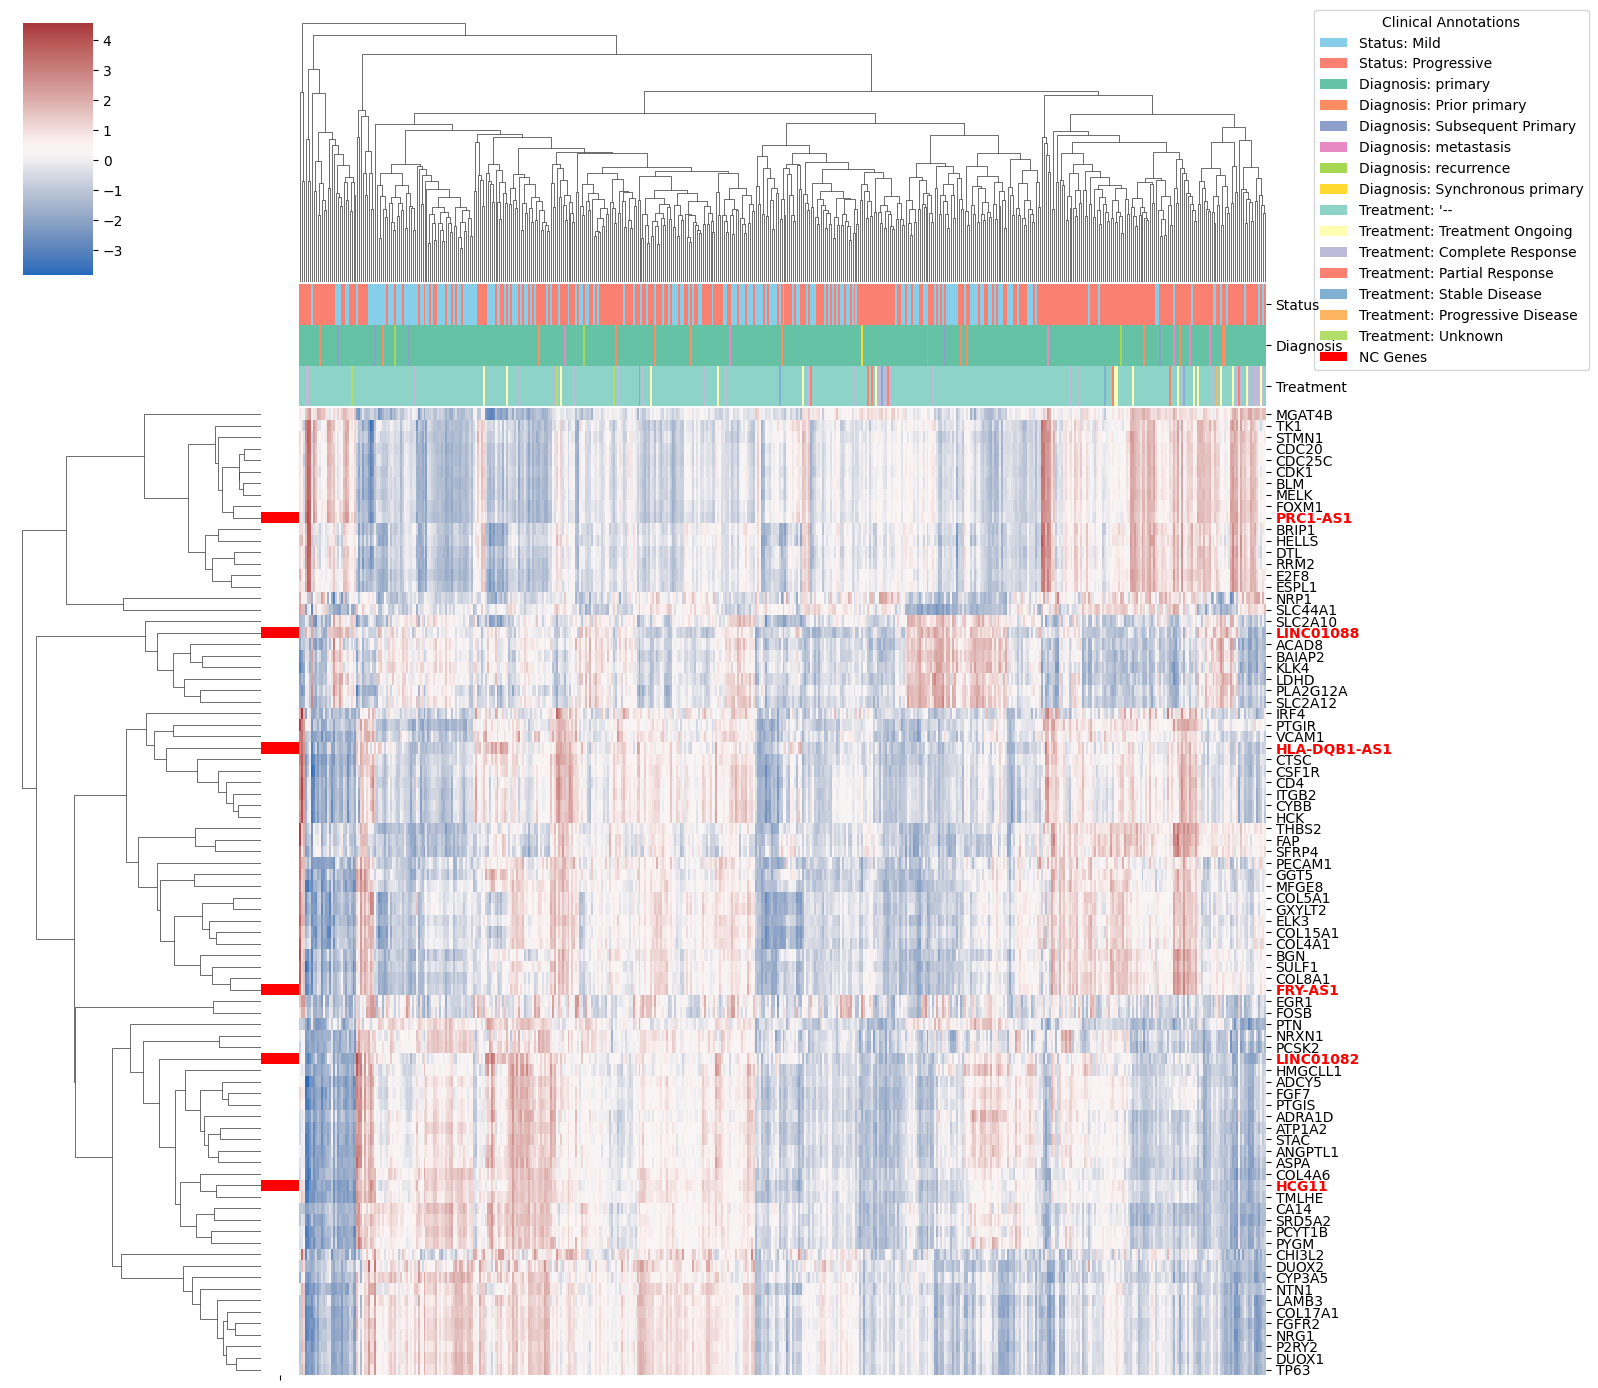

In [81]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# -------------------------------
# Load data
# -------------------------------
count_matrix = pd.read_csv("../../data/TCGA/activity_ens.csv", index_col=0)
clinical = pd.read_excel("../../data/TCGA/clinical_info.xlsx")

# Set Sample_ID as index
clinical = clinical.set_index('Sample_ID')

# Keep only samples present in both datasets
common_samples = count_matrix.columns.intersection(clinical.index)
count_matrix = count_matrix[common_samples]
clinical = clinical.loc[common_samples]

# Subset genes of interest
genes_of_interest = res_tcga_filt['ID'].tolist()
count_matrix_subset = count_matrix.loc[count_matrix.index.intersection(genes_of_interest)]

# -------------------------------
# Create color palettes for annotations
# -------------------------------
status_colors = {'Mild': 'skyblue', 'Progressive': 'salmon'}
diagnosis_colors = {cls: color for cls, color in zip(
    clinical['diagnoses.classification_of_tumor'].unique(),
    sns.color_palette("Set2", n_colors=clinical['diagnoses.classification_of_tumor'].nunique())
)}
treatment_colors = {out: color for out, color in zip(
    clinical['treatments.treatment_outcome'].unique(),
    sns.color_palette("Set3", n_colors=clinical['treatments.treatment_outcome'].nunique())
)}

# Map clinical annotations to colors
col_colors = pd.DataFrame({
    'Status': clinical['Status'].map(status_colors),
    'Diagnosis': clinical['diagnoses.classification_of_tumor'].map(diagnosis_colors),
    'Treatment': clinical['treatments.treatment_outcome'].map(treatment_colors)
})

# -------------------------------
# Highlight NC genes
# -------------------------------
nc_genes = res_tcga_filt[res_tcga_filt['Type'] == "NC"]['ID'].tolist()

# Row colors for NC genes (red), others white
row_colors = count_matrix_subset.index.to_series().apply(lambda x: 'red' if x in nc_genes else 'white')

# -------------------------------
# Plot clustered heatmap
# -------------------------------
g = sns.clustermap(
    count_matrix_subset,
    cmap="vlag",
    z_score=0,           # row-wise z-score normalization
    row_cluster=True,
    col_cluster=True,
    col_colors=col_colors,
    row_colors=row_colors,
    xticklabels=False,
    yticklabels=True,
    figsize=(14, 14)
)

# Bold yticklabels for NC genes
for label in g.ax_heatmap.get_yticklabels():
    if label.get_text() in nc_genes:
        label.set_fontweight('bold')
        label.set_color('red')

# -------------------------------
# Create legends
# -------------------------------
legend_patches = []
for label, color in status_colors.items():
    legend_patches.append(Patch(facecolor=color, label=f'Status: {label}'))
for label, color in diagnosis_colors.items():
    legend_patches.append(Patch(facecolor=color, label=f'Diagnosis: {label}'))
for label, color in treatment_colors.items():
    legend_patches.append(Patch(facecolor=color, label=f'Treatment: {label}'))
legend_patches.append(Patch(facecolor='red', label='NC Genes'))

# Add legend outside the heatmap
g.ax_col_dendrogram.legend(
    handles=legend_patches,
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.,
    title='Clinical Annotations'
)

# -------------------------------
# Save figure
# -------------------------------
#g.fig.savefig("../../figures/TCGA_clustermap_with_labels_and_NC_genes.png", dpi=300, bbox_inches='tight')
plt.show()
